# Параметризованные эксперименты: модель Росса

Исследование влияния числа запасных машин (S), количества
ремонтников и числа работающих машин (N) на среднее время
до падения системы.

In [1]:
using DrWatson
@quickactivate "project"
using ResumableFunctions
using ConcurrentSim
using Distributions
using StableRNGs
using DataFrames
using Statistics
using CSV
using Plots

## Конфигурации экспериментальных прогонов

In [2]:
param_sets = [
    (N = 10, S = 1, repairers = 1, lambda = 100.0, mu = 1.0, label = "S=1, R=1"),
    (N = 10, S = 3, repairers = 1, lambda = 100.0, mu = 1.0, label = "S=3, R=1"),
    (N = 10, S = 5, repairers = 1, lambda = 100.0, mu = 1.0, label = "S=5, R=1"),
    (N = 10, S = 3, repairers = 2, lambda = 100.0, mu = 1.0, label = "S=3, R=2"),
    (N = 10, S = 3, repairers = 3, lambda = 100.0, mu = 1.0, label = "S=3, R=3"),
    (N = 5,  S = 2, repairers = 1, lambda = 100.0, mu = 1.0, label = "N=5, S=2"),
    (N = 15, S = 5, repairers = 1, lambda = 100.0, mu = 1.0, label = "N=15, S=5"),
]

RUNS = 30
SEED = 42

42

## Приближённая аналитическая формула

In [3]:
function analytical_estimate(N, S, λ, μ)
    λ_total = N / λ
    reserve_factor = S + 1
    return reserve_factor / max(λ_total - μ, 1e-6)
end

analytical_estimate (generic function with 1 method)

## Процесс работы и отказа машины

In [4]:
@resumable function machine(
    env::Environment,
    repair_facility::Resource,
    spares::Store{Process},
    repair_queue_log,
    working_log,
    rng,
    F,
    G,
    N,
)
    while true
        try
            @yield timeout(env, Inf)
        catch
        end
        @yield timeout(env, rand(rng, F))
        current_working = N + length(spares.items) - 1
        push!(working_log, (now(env), current_working))
        get_spare = take!(spares)
        push!(repair_queue_log, (now(env), length(repair_facility.put_queue)))
        @yield get_spare | timeout(env)
        if state(get_spare) != ConcurrentSim.idle
            @yield interrupt(value(get_spare))
        else
            throw(StopSimulation("No more spares!"))
        end
        req = request(repair_facility)
        @yield req
        @yield timeout(env, rand(rng, G))
        @yield unlock(repair_facility)
        @yield put!(spares, active_process(env))
    end
end

machine (generic function with 1 method)

## Стартовая инициализация системы

In [5]:
@resumable function start_sim(
    env::Environment,
    repair_facility::Resource,
    spares::Store{Process},
    repair_queue_log,
    working_log,
    rng,
    F,
    G,
    N,
    S,
)
    for i in 1:N
        proc = @process machine(env, repair_facility, spares, repair_queue_log, working_log, rng, F, G, N)
        @yield interrupt(proc)
    end
    for i in 1:S
        proc = @process machine(env, repair_facility, spares, repair_queue_log, working_log, rng, F, G, N)
        @yield put!(spares, proc)
    end
end

start_sim (generic function with 1 method)

## Однократная симуляция

In [6]:
function single_run(N, S, repairers, lambda, mu, seed)
    rng = StableRNG(seed)
    F = Exponential(lambda)
    G = Exponential(mu)
    sim = Simulation()
    repair_facility = Resource(sim, repairers)
    spares = Store{Process}(sim)
    repair_queue_log = DataFrame(time = Float64[], queue = Int[])
    working_log = DataFrame(time = Float64[], working = Int[])
    @process start_sim(sim, repair_facility, spares, repair_queue_log, working_log, rng, F, G, N, S)
    run(sim)
    crash_time = now(sim)
    avg_queue = isempty(repair_queue_log.queue) ? 0.0 : mean(repair_queue_log.queue)
    return crash_time, avg_queue
end

single_run (generic function with 1 method)

## Многократные прогоны для усреднения

In [7]:
function multiple_runs(N, S, repairers, lambda, mu, runs)
    crash_times = Float64[]
    queue_means = Float64[]
    for run_id in 1:runs
        crash_time, avg_queue = single_run(N, S, repairers, lambda, mu, SEED + run_id)
        push!(crash_times, crash_time)
        push!(queue_means, avg_queue)
    end
    return mean(crash_times), minimum(crash_times), maximum(crash_times), mean(queue_means)
end

multiple_runs (generic function with 1 method)

## Выполнение серии экспериментов

In [8]:
results = []

for params in param_sets
    println("Запуск: $(params.label)")
    avg_crash, min_crash, max_crash, avg_queue = multiple_runs(params.N, params.S, params.repairers, params.lambda, params.mu, RUNS)
    analytical = analytical_estimate(params.N, params.S, params.lambda, params.mu)
    push!(results, merge(params, (
        avg_crash = avg_crash,
        min_crash = min_crash,
        max_crash = max_crash,
        avg_queue = avg_queue,
        analytical = analytical,
    )))
end

Запуск: S=1, R=1
Запуск: S=3, R=1
Запуск: S=5, R=1
Запуск: S=3, R=2
Запуск: S=3, R=3
Запуск: N=5, S=2
Запуск: N=15, S=5


## Сводная таблица результатов

In [9]:
df = DataFrame(results)
println("\n=== Сводная таблица ===")
show(df, allcols=true)
CSV.write(datadir("ross_param_study.csv"), df)


=== Сводная таблица ===
7×11 DataFrame
 Row │ N      S      repairers  lambda   mu       label      avg_crash      min_crash    max_crash      avg_queue    analytical
     │ Int64  Int64  Int64      Float64  Float64  String     Float64        Float64      Float64        Float64      Float64
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │    10      1          1    100.0      1.0  S=1, R=1     103.67           1.11774    284.548      0.0               2.0e6
   2 │    10      3          1    100.0      1.0  S=3, R=1   10700.9          476.898    38793.6        0.0167385         4.0e6
   3 │    10      5          1    100.0      1.0  S=5, R=1       9.20469e5  10657.5          2.89982e6  0.0115075         6.0e6
   4 │    10      3          2    100.0      1.0  S=3, R=2   62170.4         3034.94         2.24183e5  0.000660198       4.0e6
   5 │    10      3          3    100.0      1.0  S=3, R=3   87119

"/home/dgavdadaev/2026-1--study--simulation-modeling/labs/lab07/project/data/ross_param_study.csv"

## Визуализация: надёжность и загрузка


Результаты сохранены в data/ и plots/


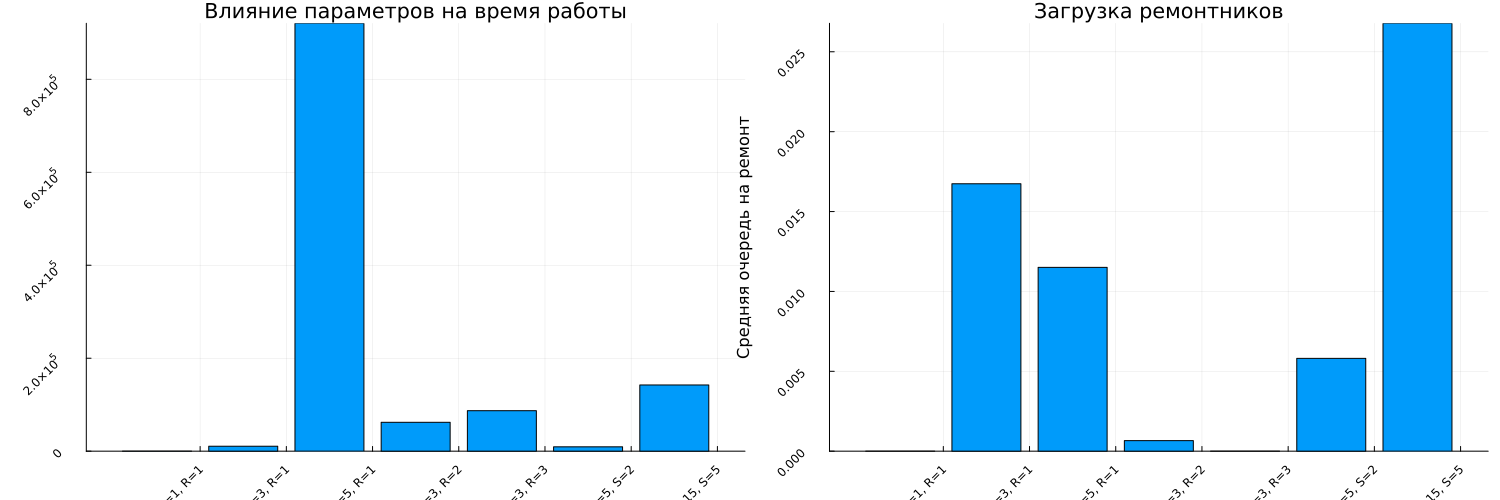

In [10]:
p1 = bar([r.label for r in results], [r.avg_crash for r in results], xlabel="Конфигурация", ylabel="Среднее время до падения", title="Влияние параметров на время работы", legend=false)
xticks!(p1, 1:length(results), [r.label for r in results], rotation=45)

p2 = bar([r.label for r in results], [r.avg_queue for r in results], xlabel="Конфигурация", ylabel="Средняя очередь на ремонт", title="Загрузка ремонтников", legend=false)
xticks!(p2, 1:length(results), [r.label for r in results], rotation=45)

final_plot = plot(p1, p2, layout=(1,2), size=(1500,500))
display(final_plot)
savefig(plotsdir("ross_param_plots.png"))

println("\nРезультаты сохранены в data/ и plots/")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*